In [ ]:
import pandas as pd

# Reemplaza 'nombre_de_tu_archivo.xlsx' con la ruta y el nombre real de tu archivo Excel
try:
    df_pozos = pd.read_excel('/content/Trayectorias_Piedemonte.xlsx')
    print("Archivo cargado exitosamente.")
    # Mostrar las primeras 5 filas del DataFrame para verificar la carga
    display(df_pozos.head())
except FileNotFoundError:
    print("Error: El archivo no fue encontrado. Por favor, verifica la ruta y el nombre del archivo.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo Excel: {e}")

Archivo cargado exitosamente.


,Pozo,MD,Incl,Azi,TVD,TVDSS,DLS,N/S,E/W,Build_Rate,Walk_Rate,Tipo
0,PSCp11,0.0,0.00,0.00,0.000000,-1836.681000,0.000000,0.000000,0.000000,0.000000,0.000000,vertical
1,PSCp11,35.5,0.00,0.00,35.500000,-1801.181000,0.000000,0.000000,0.000000,0.000000,0.000000,vertical
2,PSCp11,165.0,0.71,243.72,164.996686,-1671.684314,0.548263,-0.355252,-0.719430,0.548263,0.000000,vertical
3,PSCp11,224.0,0.58,244.03,223.992935,-1612.688065,0.220418,-0.647869,-1.315664,-0.220339,0.525424,vertical
4,PSCp11,306.0,0.36,234.29,305.990138,-1530.690862,0.284487,-0.979974,-1.897963,-0.268293,-11.878049,vertical


In [ ]:
import numpy as np
import pandas as pd

def calculate_n_counter(delta_series):
    n_counter_values = []
    current_n_counter = 1
    prev_effective_sign = None # Stores the sign of the last non-zero Delta encountered for comparison
    skip_next_row_inflection_check = False # Flag to skip increment for the *immediate* row after an inflection

    for idx, delta_val in enumerate(delta_series):
        if pd.isna(delta_val):
            n_counter_values.append(current_n_counter)
            skip_next_row_inflection_check = False # Reset states if NaN encountered
            prev_effective_sign = None # Reset effective sign when sequence is broken by NaN
            continue

        current_sign = np.sign(delta_val);

        if idx == 0: # First row for this Pozo (within the grouped series)
            n_counter_values.append(current_n_counter) # Always 1
            if current_sign != 0:
                prev_effective_sign = current_sign
            skip_next_row_inflection_check = False
        elif idx == 1: # Second row for this Pozo (within the grouped series)
            n_counter_values.append(current_n_counter) # Always 1 as per user's explicit instruction
            if current_sign != 0: # Update prev_effective_sign for comparison for row 2 (original index 3)
                prev_effective_sign = current_sign
            skip_next_row_inflection_check = False
        else: # Third row onwards
            if skip_next_row_inflection_check:
                # This row is immediately after an inflection, so we apply the already incremented counter
                n_counter_values.append(current_n_counter)
                skip_next_row_inflection_check = False # Reset for normal check on the *next* row
                if current_sign != 0:
                    prev_effective_sign = current_sign # Update prev_effective_sign for future checks
            elif current_sign != 0 and prev_effective_sign is not None and current_sign != prev_effective_sign:
                # Sign change detected, this is an inflection point
                current_n_counter += 1 # Increment for THIS inflection point
                n_counter_values.append(current_n_counter)
                skip_next_row_inflection_check = True # Mark that we should skip checking the *next* row
                if current_sign != 0:
                    prev_effective_sign = current_sign # Update prev_effective_sign
            else:
                # No sign change, no previous inflection to skip
                n_counter_values.append(current_n_counter)
                if current_sign != 0:
                    prev_effective_sign = current_sign # Update prev_effective_sign

    return pd.Series(n_counter_values, index=delta_series.index)

# --- Revised function to calculate Lc, Lx, Lc_Lx_ratio with dynamic reference points --- #
def calculate_lc_lx_for_pozo_and_n(pozo_group, n_column_name):
    lc_series = []
    lx_series = []
    lc_lx_ratio_series = []

    current_segment_ref_data = None # Will store the reference point for the *current* n_value segment

    for i in range(len(pozo_group)):
        current_row = pozo_group.iloc[i]

        md_curr = current_row['MD']
        ns_curr = current_row['N/S']
        ew_curr = current_row['E/W']
        tvd_curr = current_row['TVD']
        n_val = current_row[n_column_name]

        # First row of the Pozo group
        if i == 0:
            lc_series.append(0.0)
            lx_series.append(0.0)
            lc_lx_ratio_series.append(0.0)

            # This row becomes the reference for the first segment
            current_segment_ref_data = {
                'MD': md_curr, 'N/S': ns_curr, 'E/W': ew_curr, 'TVD': tvd_curr
            }
            continue

        # Get n_val of the previous row in this specific Pozo group
        prev_n_val_in_group = pozo_group.iloc[i-1][n_column_name]

        ref_md, ref_ns, ref_ew, ref_tvd = 0, 0, 0, 0 # Initialize to avoid UnboundLocalError

        # Determine if this row is the start of a new 'n' segment
        if n_val != prev_n_val_in_group:
            # This is an inflection point. Its calculations should be relative to the *previous* segment's start.
            # The current_segment_ref_data holds the start of the segment that just ended (prev_n_val_in_group).
            ref_point_for_inflection_calc = current_segment_ref_data

            ref_md = ref_point_for_inflection_calc['MD']
            ref_ns = ref_point_for_inflection_calc['N/S']
            ref_ew = ref_point_for_inflection_calc['E/W']
            ref_tvd = ref_point_for_inflection_calc['TVD']

            # After this calculation, update the current segment reference to *this* row (the inflection point)
            current_segment_ref_data = {
                'MD': md_curr, 'N/S': ns_curr, 'E/W': ew_curr, 'TVD': tvd_curr
            }

        else:
            # Not an inflection point (n_val is same as prev_n_val_in_group).
            # Use the *current* segment's start (which was set at the last inflection or start of Pozo) as reference.
            ref_md = current_segment_ref_data['MD']
            ref_ns = current_segment_ref_data['N/S']
            ref_ew = current_segment_ref_data['E/W']
            ref_tvd = current_segment_ref_data['TVD']

        # Calculate Lc
        lc = md_curr - ref_md
        lc_series.append(lc)

        # Calculate Lx
        delta_ns = ns_curr - ref_ns
        delta_ew = ew_curr - ref_ew
        delta_tvd = tvd_curr - ref_tvd
        lx = np.sqrt(delta_ns**2 + delta_ew**2 + delta_tvd**2)
        lx_series.append(lx)

        # Calculate Lc_Lx_ratio
        lc_lx_ratio = lc / lx if lx != 0 else 0
        lc_lx_ratio_series.append(lc_lx_ratio)

    return pd.DataFrame({
        'Lc': lc_series,
        'Lx': lx_series,
        'Lc_Lx_ratio': lc_lx_ratio_series
    }, index=pozo_group.index) # Preserve original index

# --- Calculations ---

# Create a copy of the original DataFrame to ensure original columns are preserved
# and to avoid issues if previous runs left unwanted columns.
df_processed = df_pozos.copy()

# Calculate Delta_inc
df_processed['Delta_inc'] = df_processed.groupby('Pozo')['Incl'].diff()

# Calculate n_inc
df_processed['n_inc'] = df_processed.groupby('Pozo')['Delta_inc'].transform(calculate_n_counter)

# Calculate Delta_azi
df_processed['Delta_azi'] = df_processed.groupby('Pozo')['Azi'].diff()

# Calculate n_azi
df_processed['n_azi'] = df_processed.groupby('Pozo')['Delta_azi'].transform(calculate_n_counter)

# Calculate Lc, Lx, Lc_Lx_ratio based on n_inc segments using the new function
inc_calculated_data = df_processed.groupby('Pozo', group_keys=False).apply(
    lambda x: calculate_lc_lx_for_pozo_and_n(x, 'n_inc')
)
# Add new columns to df_processed using direct assignment
for col in ['Lc', 'Lx', 'Lc_Lx_ratio']:
    df_processed[f'{col}_inc'] = inc_calculated_data[col]

# Calculate Lc, Lx, Lc_Lx_ratio based on n_azi segments using the new function
azi_calculated_data = df_processed.groupby('Pozo', group_keys=False).apply(
    lambda x: calculate_lc_lx_for_pozo_and_n(x, 'n_azi')
)
# Add new columns to df_processed using direct assignment
for col in ['Lc', 'Lx', 'Lc_Lx_ratio']:
    df_processed[f'{col}_azi'] = azi_calculated_data[col]

# Define the final set of columns to keep.
# This explicitly selects all original columns PLUS the new calculated ones,
# ensuring no unintended columns (like generic 'Lc', 'Lx', 'Lc_Lx_ratio' or suffixed _x, _y ones) remain.
desired_final_columns = [
    'Pozo', 'MD', 'Incl', 'Azi', 'TVD', 'TVDSS', 'DLS', 'N/S', 'E/W', 'Build_Rate', 'Walk_Rate', 'Tipo',
    'Delta_inc', 'n_inc', 'Delta_azi', 'n_azi',
    'Lc_inc', 'Lx_inc', 'Lc_Lx_ratio_inc',
    'Lc_azi', 'Lx_azi', 'Lc_Lx_ratio_azi'
]

# Filter the DataFrame to keep only the desired columns
# Ensure that all desired_final_columns actually exist in df_processed before selection
existing_desired_columns = [col for col in desired_final_columns if col in df_processed.columns]
df_processed = df_processed[existing_desired_columns]


print("Todos los cálculos han sido completados y el DataFrame ha sido limpiado.")
print("Primeras filas del DataFrame con las columnas actualizadas y limpias:")
display(df_processed.head())

# --- Export to Excel ---
output_file_path = '/content/Trayectorias_Piedemonte_Calculado.xlsx'
try:
    df_processed.to_excel(output_file_path, index=False)
    print(f"DataFrame exportado exitosamente a '{output_file_path}'")
except Exception as e:
    print(f"Ocurrió un error al exportar el archivo Excel: {e}")

# Reassign df_pozos to df_processed for continuity with previous cell's naming
df_pozos = df_processed

/tmp/ipykernel_375/3355125461.py:149: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inc_calculated_data = df_processed.groupby('Pozo', group_keys=False).apply(


Todos los cálculos han sido completados y el DataFrame ha sido limpiado.
Primeras filas del DataFrame con las columnas actualizadas y limpias:


/tmp/ipykernel_375/3355125461.py:157: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  azi_calculated_data = df_processed.groupby('Pozo', group_keys=False).apply(


,Pozo,MD,Incl,Azi,TVD,TVDSS,DLS,N/S,E/W,Build_Rate,...,Delta_inc,n_inc,Delta_azi,n_azi,Lc_inc,Lx_inc,Lc_Lx_ratio_inc,Lc_azi,Lx_azi,Lc_Lx_ratio_azi
0,PSCp11,0.0,0.00,0.00,0.000000,-1836.681000,0.000000,0.000000,0.000000,0.000000,...,NaN,1,NaN,1,0.0,0.000000,0.000000,0.0,0.000000,0.000000
1,PSCp11,35.5,0.00,0.00,35.500000,-1801.181000,0.000000,0.000000,0.000000,0.000000,...,0.00,1,0.00,1,35.5,35.500000,1.000000,35.5,35.500000,1.000000
2,PSCp11,165.0,0.71,243.72,164.996686,-1671.684314,0.548263,-0.355252,-0.719430,0.548263,...,0.71,1,243.72,1,165.0,164.998637,1.000008,165.0,164.998637,1.000008
3,PSCp11,224.0,0.58,244.03,223.992935,-1612.688065,0.220418,-0.647869,-1.315664,-0.220339,...,-0.13,2,0.31,1,224.0,223.997735,1.000010,224.0,223.997735,1.000010
4,PSCp11,306.0,0.36,234.29,305.990138,-1530.690862,0.284487,-0.979974,-1.897963,-0.268293,...,-0.22,2,-9.74,2,82.0,81.999943,1.000001,306.0,305.997593,1.000008


DataFrame exportado exitosamente a '/content/Trayectorias_Piedemonte_Calculado.xlsx'


In [ ]:
# Calculate T_inc
df_processed['Lc_Lx_ratio_inc_minus_1'] = df_processed['Lc_Lx_ratio_inc'] - 1
# Set the first value for each Pozo to 0, as per instruction
df_processed.loc[df_processed.groupby('Pozo').head(1).index, 'Lc_Lx_ratio_inc_minus_1'] = 0
# Calculate cumulative sum grouped only by Pozo
df_processed['cumulative_sum_inc'] = df_processed.groupby('Pozo')['Lc_Lx_ratio_inc_minus_1'].cumsum()

# Handle division by zero for MD
df_processed['T_inc'] = df_processed.apply(
    lambda row: (row['n_inc'] / row['MD']) * row['cumulative_sum_inc'] if row['MD'] != 0 else 0,
    axis=1
)

# Calculate T_azi
df_processed['Lc_Lx_ratio_azi_minus_1'] = df_processed['Lc_Lx_ratio_azi'] - 1
# Set the first value for each Pozo to 0, as per instruction
df_processed.loc[df_processed.groupby('Pozo').head(1).index, 'Lc_Lx_ratio_azi_minus_1'] = 0
# Calculate cumulative sum grouped only by Pozo
df_processed['cumulative_sum_azi'] = df_processed.groupby('Pozo')['Lc_Lx_ratio_azi_minus_1'].cumsum()

# Handle division by zero for MD
df_processed['T_azi'] = df_processed.apply(
    lambda row: (row['n_azi'] / row['MD']) * row['cumulative_sum_azi'] if row['MD'] != 0 else 0,
    axis=1
)

# Calculate T_tot
df_processed['T_tot'] = np.sqrt(df_processed['T_inc']**2 + df_processed['T_azi']**2)

# NOTE: Removed the drop of intermediate columns so they appear in the exported Excel.
# df_processed = df_processed.drop(columns=['Lc_Lx_ratio_inc_minus_1', 'cumulative_sum_inc', 'Lc_Lx_ratio_azi_minus_1', 'cumulative_sum_azi'])

output_file_path_final = '/content/Trayectorias_Piedemonte_Final.xlsx'
try:
    # Ensure df_processed is exported, not df_pozos
    df_processed.to_excel(output_file_path_final, index=False)
    print(f"DataFrame final exportado exitosamente a '{output_file_path_final}'")
except Exception as e:
    print(f"Ocurrió un error al exportar el archivo Excel: {e}")

print("Índices de tortuosidad T_inc, T_azi y T_tot calculados.")
display(df_processed.head())

DataFrame final exportado exitosamente a '/content/Trayectorias_Piedemonte_Final.xlsx'
Índices de tortuosidad T_inc, T_azi y T_tot calculados.


,Pozo,MD,Incl,Azi,TVD,TVDSS,DLS,N/S,E/W,Build_Rate,...,Lc_azi,Lx_azi,Lc_Lx_ratio_azi,T_inc,T_azi,Lc_Lx_ratio_inc_minus_1,cumulative_sum_inc,Lc_Lx_ratio_azi_minus_1,cumulative_sum_azi,T_tot
0,PSCp11,0.0,0.00,0.00,0.000000,-1836.681000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
1,PSCp11,35.5,0.00,0.00,35.500000,-1801.181000,0.000000,0.000000,0.000000,0.000000,...,35.5,35.500000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
2,PSCp11,165.0,0.71,243.72,164.996686,-1671.684314,0.548263,-0.355252,-0.719430,0.548263,...,165.0,164.998637,1.000008,5.007841e-08,5.007841e-08,8.262938e-06,0.000008,0.000008,0.000008,7.082157e-08
3,PSCp11,224.0,0.58,244.03,223.992935,-1612.688065,0.220418,-0.647869,-1.315664,-0.220339,...,224.0,223.997735,1.000010,1.640420e-07,8.202098e-08,1.010976e-05,0.000018,0.000010,0.000018,1.834045e-07
4,PSCp11,306.0,0.36,234.29,305.990138,-1530.690862,0.284487,-0.979974,-1.897963,-0.268293,...,306.0,305.997593,1.000008,1.245975e-07,1.714882e-07,6.907118e-07,0.000019,0.000008,0.000026,2.119734e-07


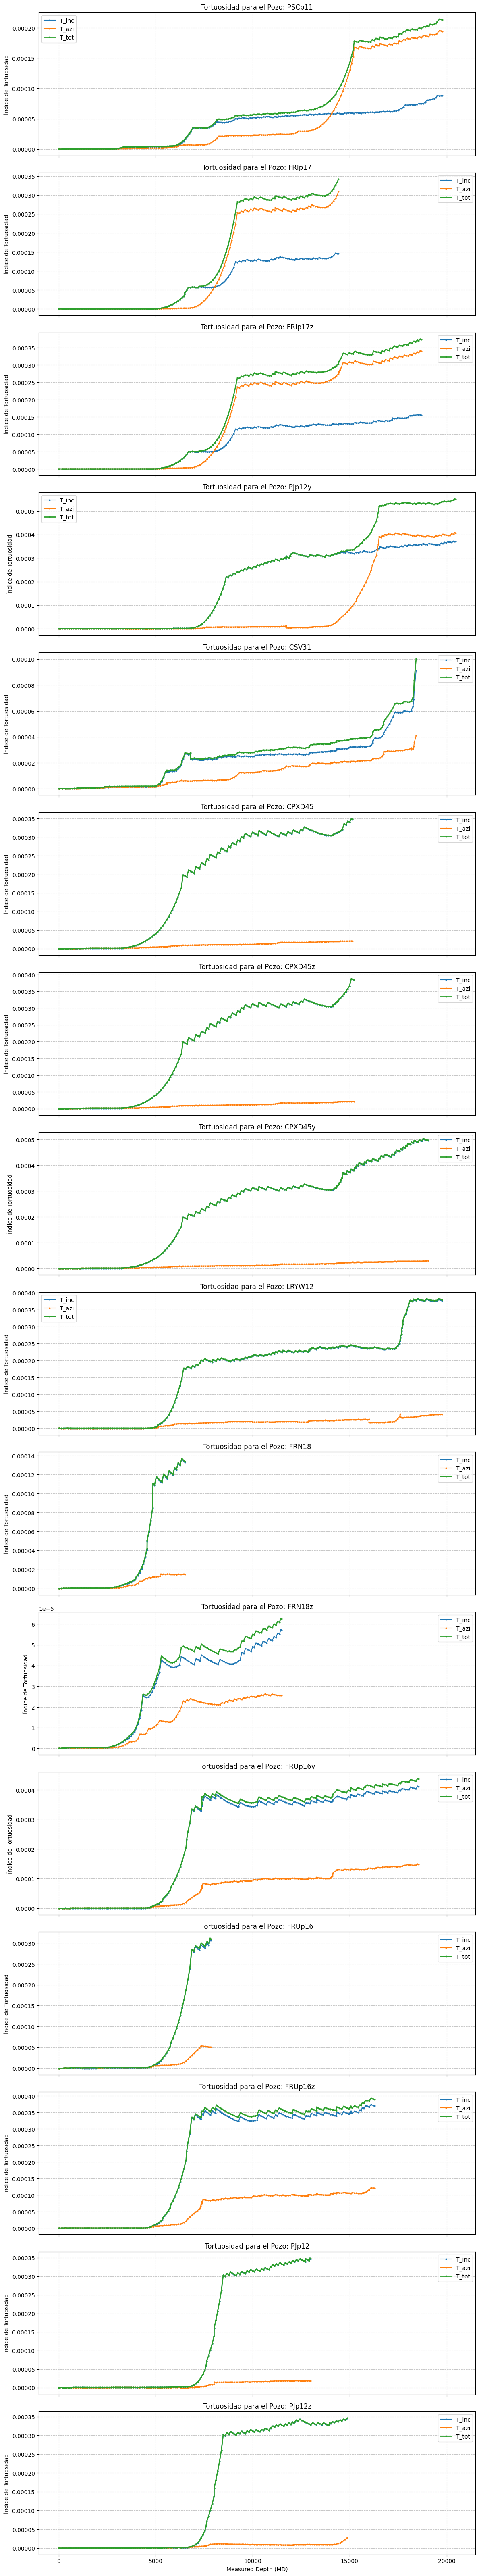

In [ ]:
import matplotlib.pyplot as plt

# Identificar todos los pozos únicos
all_pozos = df_processed['Pozo'].unique()

# Crear una figura y subplots para cada pozo
# Ajustar el tamaño de la figura dinámicamente según el número de pozos
fig, axes = plt.subplots(nrows=len(all_pozos), ncols=1, figsize=(12, 4 * len(all_pozos)), sharex=True)

# Asegurarse de que axes sea un array si solo hay un pozo
if len(all_pozos) == 1:
    axes = [axes]

for i, pozo_name in enumerate(all_pozos):
    # Filtrar el DataFrame para el pozo actual
    df_pozo = df_processed[df_processed['Pozo'] == pozo_name]

    # Plotear T_inc, T_azi y T_tot en el mismo track (subplot)
    axes[i].plot(df_pozo['MD'], df_pozo['T_inc'], label='T_inc', marker='.', markersize=4, linestyle='-')
    axes[i].plot(df_pozo['MD'], df_pozo['T_azi'], label='T_azi', marker='.', markersize=4, linestyle='-')
    axes[i].plot(df_pozo['MD'], df_pozo['T_tot'], label='T_tot', marker='.', markersize=4, linestyle='-', linewidth=2)

    # Configuración del gráfico
    axes[i].set_title(f'Tortuosidad para el Pozo: {pozo_name}')
    axes[i].set_ylabel('Índice de Tortuosidad')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Configuración global del eje X
axes[-1].set_xlabel('Measured Depth (MD)')

plt.tight_layout()
plt.show()

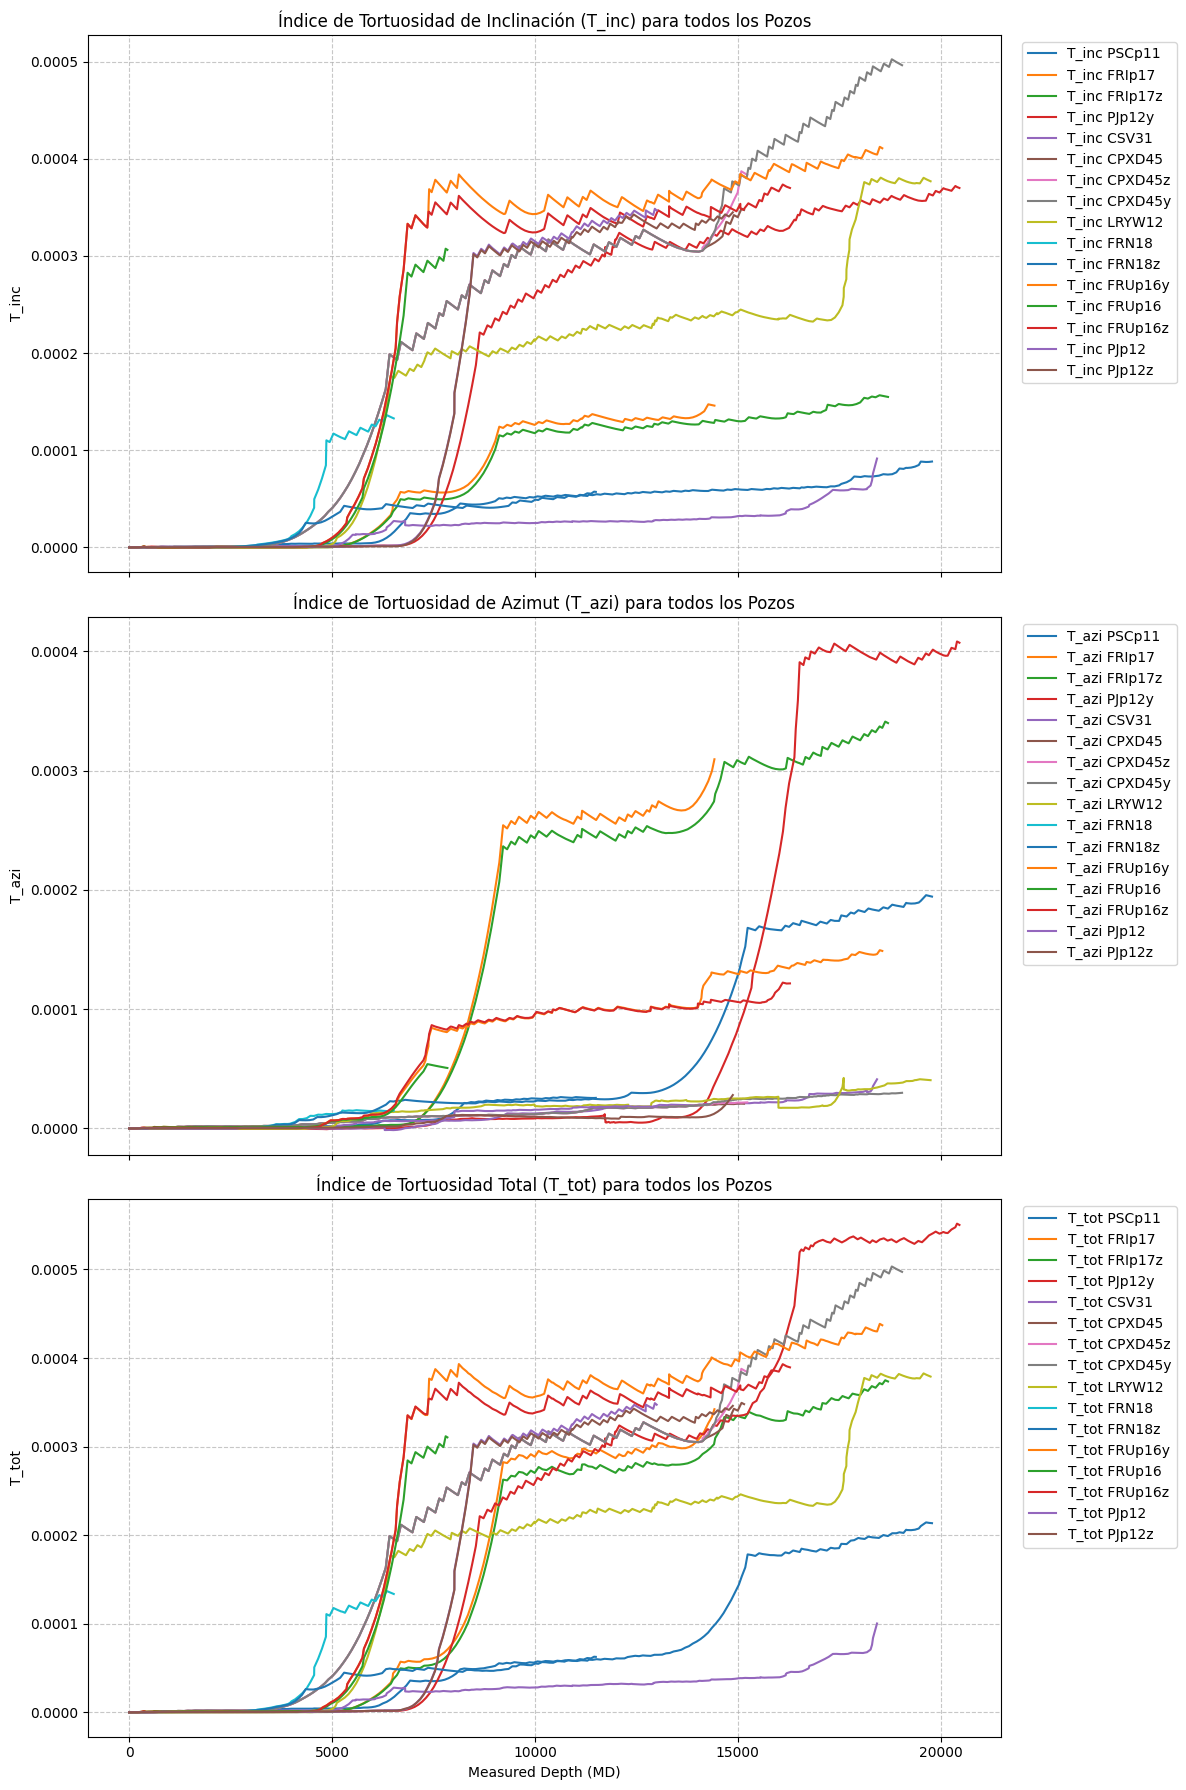

In [ ]:
import matplotlib.pyplot as plt

# Identificar todos los pozos únicos
all_pozos = df_processed['Pozo'].unique()

# Crear una figura con tres subplots (uno para T_inc, uno para T_azi, uno para T_tot)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)

# Plotear T_inc para todos los pozos
for pozo_name in all_pozos:
    df_pozo = df_processed[df_processed['Pozo'] == pozo_name]
    axes[0].plot(df_pozo['MD'], df_pozo['T_inc'], label=f'T_inc {pozo_name}')
axes[0].set_title('Índice de Tortuosidad de Inclinación (T_inc) para todos los Pozos')
axes[0].set_ylabel('T_inc')
axes[0].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plotear T_azi para todos los pozos
for pozo_name in all_pozos:
    df_pozo = df_processed[df_processed['Pozo'] == pozo_name]
    axes[1].plot(df_pozo['MD'], df_pozo['T_azi'], label=f'T_azi {pozo_name}')
axes[1].set_title('Índice de Tortuosidad de Azimut (T_azi) para todos los Pozos')
axes[1].set_ylabel('T_azi')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plotear T_tot para todos los pozos
for pozo_name in all_pozos:
    df_pozo = df_processed[df_processed['Pozo'] == pozo_name]
    axes[2].plot(df_pozo['MD'], df_pozo['T_tot'], label=f'T_tot {pozo_name}')
axes[2].set_title('Índice de Tortuosidad Total (T_tot) para todos los Pozos')
axes[2].set_xlabel('Measured Depth (MD)')
axes[2].set_ylabel('T_tot')
axes[2].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

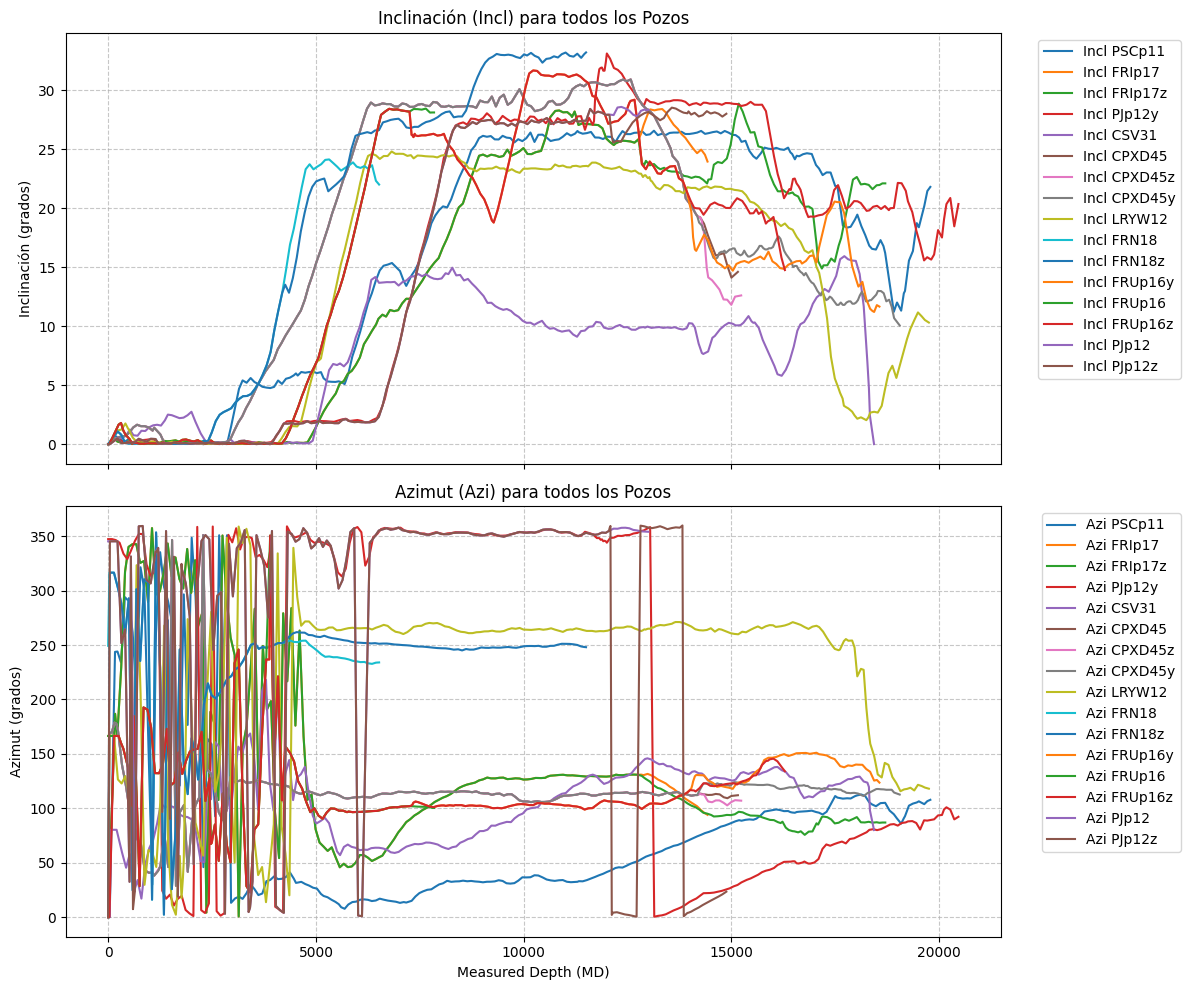

In [ ]:
import matplotlib.pyplot as plt

# Identificar todos los pozos únicos
all_pozos = df_processed['Pozo'].unique()

# Crear una figura con dos subplots (uno para Incl, otro para Azi)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Plotear Incl para todos los pozos
for pozo_name in all_pozos:
    df_pozo = df_processed[df_processed['Pozo'] == pozo_name]
    axes[0].plot(df_pozo['MD'], df_pozo['Incl'], label=f'Incl {pozo_name}')
axes[0].set_title('Inclinación (Incl) para todos los Pozos')
axes[0].set_ylabel('Inclinación (grados)')
axes[0].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plotear Azi para todos los pozos
for pozo_name in all_pozos:
    df_pozo = df_processed[df_processed['Pozo'] == pozo_name]
    axes[1].plot(df_pozo['MD'], df_pozo['Azi'], label=f'Azi {pozo_name}')
axes[1].set_title('Azimut (Azi) para todos los Pozos')
axes[1].set_xlabel('Measured Depth (MD)')
axes[1].set_ylabel('Azimut (grados)')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()